# 01. Statistical Learning for Decision Systems

Machine learning is often taught as a sequence of algorithms. For decision science, that is too narrow. The real question is whether a model fits data well and whether it helps an organization make better choices under uncertainty.

This lecture introduces statistical learning from that broader point of view. We will work through a synthetic account-operations case study in which a software company wants to predict support burden, identify accounts at high risk of service failure, and discover natural segments that might need different operating policies.

The notebook is deliberately balanced across supervised and unsupervised learning. Prediction, classification, segmentation, and structure discovery all belong in a modern decision-science workflow. The key discipline is to keep them connected to operational action rather than treating them as isolated technical exercises.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain why machine learning in decision science begins with an action problem rather than a library call.
2. Distinguish supervised and unsupervised learning in terms of what information is available and what decision need is being served.
3. Build baseline regression and classification models for an operational dataset.
4. Interpret performance metrics in terms of business cost rather than only statistical convenience.
5. Use clustering and low-dimensional visualization to discover structure in unlabeled data.
6. Translate model scores and learned segments into a professional recommendation for action.
7. Explain why predictive learning supports decisions but does not, by itself, establish causal effects.

In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    r2_score,
    silhouette_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "notebooks" / "_shared").exists())
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 40)

## 1. Start With the Decision Problem

A useful way to summarize statistical learning is:

$$
f^* = \arg \min_f \; \mathbb{E}[L(Y, f(X))].
$$

The symbol $X$ represents available information, $Y$ is the quantity we care to predict or summarize, and $L$ is the loss attached to being wrong. In practice, the loss function is where decision science lives. It encodes what kinds of errors are cheap, what kinds are costly, and which actions depend on the output.

This means the first question is not, "Should I use a forest or a neural network?" The first question is, "What decision changes if this model is good enough?"

| Element | Case-study framing |
|---|---|
| Organization | B2B software platform |
| Unit | One account-month |
| Primary decisions | Which accounts need proactive success outreach, specialist support, or standard digital support? |
| Supervised targets | `support_hours_next_30d` and `sla_breach_next_30d` |
| Unsupervised goal | Discover account segments with different operating profiles |
| Cost of underreaction | High-risk accounts may breach service commitments and churn |
| Cost of overreaction | Teams may waste scarce specialist capacity on accounts that do not need it |
| Practical objective | Build decision support around predictive accuracy |


### Supervised and Unsupervised Learning Serve Different Needs

| Learning mode | What is observed? | Typical output | Decision-science use |
|---|---|---|---|
| Supervised learning | Features and labeled outcomes | Predicted value, class, or probability | Forecast support load, rank risk, prioritize intervention |
| Unsupervised learning | Features only | Segments, latent structure, lower-dimensional representation | Discover account types, tailor workflows, design differentiated policies |

The distinction is not philosophical. It changes what can be learned and how the result should be used. A supervised model can directly rank units by predicted risk or expected workload. An unsupervised procedure cannot do that, but it can uncover structure that helps analysts reason about heterogeneity and operating design.

### Mathematical Spine: Population Risk, Empirical Risk, and Model Class Choice

A useful way to formalize statistical learning is to separate the **population problem** from the **sample-based approximation** we can actually solve. If outcomes are generated from an unknown joint distribution for features and outcomes, then the ideal predictor for a loss function \(L\) solves

$$
f^* = \arg\min_f R(f), \qquad R(f) = \mathbb{E}[L(Y, f(X))].
$$

Here \(R(f)\) is the **population risk**: the long-run average penalty we would incur if we repeatedly applied predictor \(f\) in the deployment environment. In practice we do not observe the whole population. We observe a sample \(\{(x_i, y_i)\}_{i=1}^n\), choose a model class \(\mathcal{F}\), and solve an empirical version:

$$
\hat f = \arg\min_{f \in \mathcal{F}} \hat R_n(f), \qquad \hat R_n(f) = \frac{1}{n}\sum_{i=1}^n L(y_i, f(x_i)).
$$

This separates two different sources of error. Even the best function inside \(\mathcal{F}\) may still be too simple for the real data-generating process, which is an **approximation** problem. And even if \(\mathcal{F}\) is flexible enough, the finite sample may lead us to a noisy estimate, which is an **estimation** problem. A clean way to say this is

$$
R(\hat f) - R(f^*)
= \underbrace{\big(R(\hat f) - \inf_{f \in \mathcal{F}} R(f)\big)}_{\text{estimation error}}
+ \underbrace{\big(\inf_{f \in \mathcal{F}} R(f) - R(f^*)\big)}_{\text{approximation error}}.
$$

That decomposition is why model choice is never just about raw predictive power. A linear model, a tree ensemble, and a clustering method each impose a different structure on \(\mathcal{F}\), and that structure determines what patterns they can or cannot recover.

For the unsupervised part of this notebook, the analogous objective no longer uses labels \(Y\). In k-means, for example, the analyst chooses cluster assignments \(c_i\) and centroids \(\mu_1, \ldots, \mu_K\) to minimize within-cluster dispersion:

$$
\min_{c_1, \ldots, c_n,\, \mu_1, \ldots, \mu_K}
\sum_{i=1}^n \lVert x_i - \mu_{c_i} \rVert_2^2.
$$

So supervised and unsupervised learning differ in whether labels are present and in the mathematical object being optimized.

## 2. Synthetic Account-Operations Dataset

We will simulate a realistic account-month dataset. Each row represents one customer account observed this month, together with outcomes realized next month.

This instructor-controlled simulation is useful because it gives us two advantages:

1. We can create nonlinear structure so that simple and complex models behave differently.
2. We can embed hidden segment structure to make the unsupervised portion meaningful.

In real work, the hidden truth is not available. Here it is only a teaching device.

For the purposes of the lecture, the row grain is deliberately concrete: one account at the end of a month. The observed fields describe recent usage, support burden, commercial context, and service quality. The simulated outcomes describe next-month support effort and breach risk. That gives the same data two roles: it can support supervised prediction, and it can also support unsupervised structure discovery.

The experiment in this notebook is a workflow experiment rather than a causal experiment. We ask what different model classes reveal about the same operating environment, how much signal a baseline captures, and whether model output can be translated into an action such as monitor, specialist review, or immediate intervention. In production, the hidden segment labels would be unavailable; they are kept here only so we can judge whether the learning workflow is behaving sensibly.


| Variable | Role | Why it matters |
|---|---|---|
| `annual_revenue_k` | Commercial scale | Larger accounts often justify more service effort and specialist attention |
| `seat_count` | Product footprint | Higher usage footprint tends to increase support demand |
| `usage_intensity` | Adoption pressure | Highly active accounts can create both opportunity and operational load |
| `integration_complexity` | Technical difficulty | Complex integrations tend to generate slower, harder support work |
| `prior_tickets_30d` | Recent workload | Recent support volume is one of the strongest leading indicators of future burden |
| `avg_response_minutes_last90d` | Service history | Existing service strain is often predictive of future failures |
| `training_completion_rate` | Enablement quality | Better trained customers usually resolve issues more efficiently |
| `feature_adoption_rate` | Product maturity | Mature product usage can reduce preventable friction |
| `contract_age_months` | Relationship stage | Newer accounts may still be stabilizing operationally |
| `plan_tier`, `industry`, `region` | Contextual structure | Operational norms and service complexity differ across settings |
| `support_hours_next_30d` | Continuous supervised target | Forecasts the burden placed on the support system |
| `sla_breach_next_30d` | Binary supervised target | Signals likely service failure and escalation risk |
| hidden `true_segment` | Instructor benchmark | Lets us assess whether clustering recovers meaningful structure |


In [2]:
# Section focus: 2. Synthetic Account-Operations Dataset.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1.0 / (1.0 + np.exp(-x))


def modal_value(series):
    """Return the most common observed category for a column in the example data.
    
    Parameters
    ----------
    series : object
        One-dimensional pandas object whose distribution or most common value is being inspected.
    
    Returns
    -------
    object
        Intermediate result produced by the modal value calculation and reused by later cells.
    """
    modes = series.mode()
    return modes.iloc[0] if not modes.empty else np.nan


def simulate_account_months(n=4800, random_state=2026):
    """Create a simulated account months data set for the 01. Statistical Learning for Decision Systems case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)

    segment_levels = np.array(
        [
            "Self-serve SMB",
            "Growth mid-market",
            "Complex enterprise",
            "Distressed high-risk",
        ]
    )
    plan_levels = np.array(["basic", "professional", "business", "enterprise"])
    industry_levels = np.array(["retail", "fintech", "healthcare", "logistics", "education"])
    region_levels = np.array(["North", "South", "West", "Central"])

    params = {
        "Self-serve SMB": {
            "revenue_mean": 42,
            "revenue_sd": 14,
            "seats_mean": 28,
            "seats_sd": 12,
            "usage_a": 2.4,
            "usage_b": 3.4,
            "complexity_a": 1.6,
            "complexity_b": 5.5,
            "training_a": 6.0,
            "training_b": 2.4,
            "adoption_a": 4.2,
            "adoption_b": 2.9,
            "ticket_lambda": 1.5,
            "contract_shape": 2.0,
            "contract_scale": 7.5,
            "plan_probs": [0.48, 0.37, 0.12, 0.03],
            "industry_probs": [0.30, 0.15, 0.10, 0.22, 0.23],
            "region_probs": [0.27, 0.21, 0.24, 0.28],
        },
        "Growth mid-market": {
            "revenue_mean": 135,
            "revenue_sd": 30,
            "seats_mean": 118,
            "seats_sd": 36,
            "usage_a": 4.5,
            "usage_b": 2.2,
            "complexity_a": 2.6,
            "complexity_b": 3.4,
            "training_a": 5.0,
            "training_b": 3.0,
            "adoption_a": 5.8,
            "adoption_b": 2.1,
            "ticket_lambda": 3.2,
            "contract_shape": 2.3,
            "contract_scale": 8.5,
            "plan_probs": [0.08, 0.38, 0.40, 0.14],
            "industry_probs": [0.18, 0.23, 0.14, 0.27, 0.18],
            "region_probs": [0.24, 0.25, 0.29, 0.22],
        },
        "Complex enterprise": {
            "revenue_mean": 380,
            "revenue_sd": 85,
            "seats_mean": 320,
            "seats_sd": 90,
            "usage_a": 5.0,
            "usage_b": 1.9,
            "complexity_a": 5.3,
            "complexity_b": 1.9,
            "training_a": 4.4,
            "training_b": 3.2,
            "adoption_a": 4.2,
            "adoption_b": 2.8,
            "ticket_lambda": 5.8,
            "contract_shape": 2.8,
            "contract_scale": 10.0,
            "plan_probs": [0.00, 0.06, 0.28, 0.66],
            "industry_probs": [0.10, 0.28, 0.25, 0.22, 0.15],
            "region_probs": [0.23, 0.19, 0.35, 0.23],
        },
        "Distressed high-risk": {
            "revenue_mean": 185,
            "revenue_sd": 48,
            "seats_mean": 145,
            "seats_sd": 44,
            "usage_a": 4.2,
            "usage_b": 2.6,
            "complexity_a": 4.2,
            "complexity_b": 2.4,
            "training_a": 2.3,
            "training_b": 5.0,
            "adoption_a": 2.2,
            "adoption_b": 4.8,
            "ticket_lambda": 6.0,
            "contract_shape": 1.8,
            "contract_scale": 6.5,
            "plan_probs": [0.04, 0.32, 0.42, 0.22],
            "industry_probs": [0.20, 0.17, 0.26, 0.25, 0.12],
            "region_probs": [0.21, 0.24, 0.33, 0.22],
        },
    }

    true_segment = rng.choice(segment_levels, size=n, p=[0.34, 0.29, 0.22, 0.15])

    annual_revenue_k = np.zeros(n)
    seat_count = np.zeros(n)
    usage_intensity = np.zeros(n)
    integration_complexity = np.zeros(n)
    training_completion_rate = np.zeros(n)
    feature_adoption_rate = np.zeros(n)
    prior_tickets_30d = np.zeros(n)
    contract_age_months = np.zeros(n)
    plan_tier = np.empty(n, dtype=object)
    industry = np.empty(n, dtype=object)
    region = np.empty(n, dtype=object)

    for segment_name, cfg in params.items():
        mask = true_segment == segment_name
        m = mask.sum()

        annual_revenue_k[mask] = np.clip(
            rng.normal(cfg["revenue_mean"], cfg["revenue_sd"], size=m),
            8,
            None,
        )
        seat_count[mask] = np.clip(
            rng.normal(cfg["seats_mean"], cfg["seats_sd"], size=m),
            5,
            None,
        )
        usage_intensity[mask] = rng.beta(cfg["usage_a"], cfg["usage_b"], size=m)
        integration_complexity[mask] = rng.beta(cfg["complexity_a"], cfg["complexity_b"], size=m)
        training_completion_rate[mask] = rng.beta(cfg["training_a"], cfg["training_b"], size=m)
        feature_adoption_rate[mask] = rng.beta(cfg["adoption_a"], cfg["adoption_b"], size=m)
        prior_tickets_30d[mask] = rng.poisson(cfg["ticket_lambda"] + 0.010 * seat_count[mask], size=m)
        contract_age_months[mask] = np.clip(
            rng.gamma(cfg["contract_shape"], cfg["contract_scale"], size=m),
            1,
            96,
        )
        plan_tier[mask] = rng.choice(plan_levels, size=m, p=cfg["plan_probs"])
        industry[mask] = rng.choice(industry_levels, size=m, p=cfg["industry_probs"])
        region[mask] = rng.choice(region_levels, size=m, p=cfg["region_probs"])

    avg_response_minutes_last90d = (
        18
        + 2.2 * prior_tickets_30d
        + 38 * integration_complexity
        - 16 * training_completion_rate
        + 0.04 * seat_count
        + 4 * (plan_tier == "enterprise")
        + rng.normal(0, 5.5, size=n)
    )
    avg_response_minutes_last90d = np.clip(avg_response_minutes_last90d, 12, 180)

    support_hours_next_30d = (
        1.5
        + 0.030 * seat_count
        + 6.5 * integration_complexity
        + 0.48 * prior_tickets_30d
        + 0.08 * avg_response_minutes_last90d
        - 4.0 * training_completion_rate
        - 2.2 * feature_adoption_rate
        - 0.015 * contract_age_months
        + 1.6 * (plan_tier == "enterprise")
        + 0.9 * (industry == "healthcare")
        + 0.7 * (industry == "fintech")
        + 4.5 * np.maximum(usage_intensity - 0.78, 0) * integration_complexity
        + rng.gamma(shape=2.0, scale=1.1, size=n)
    )
    support_hours_next_30d = np.clip(support_hours_next_30d, 1, None)

    sla_logit = (
        -6.4
        + 0.17 * support_hours_next_30d
        + 0.80 * integration_complexity
        + 0.05 * prior_tickets_30d
        + 0.012 * avg_response_minutes_last90d
        - 0.9 * training_completion_rate
        - 0.45 * feature_adoption_rate
        + 0.55 * (region == "West")
        + 0.35 * (industry == "healthcare")
        + 0.75 * (true_segment == "Distressed high-risk")
    )
    sla_prob = sigmoid(sla_logit)
    sla_breach_next_30d = rng.binomial(1, np.clip(sla_prob, 0.03, 0.94))

    frame = pd.DataFrame(
        {
            "annual_revenue_k": annual_revenue_k,
            "seat_count": seat_count,
            "usage_intensity": usage_intensity,
            "integration_complexity": integration_complexity,
            "prior_tickets_30d": prior_tickets_30d,
            "avg_response_minutes_last90d": avg_response_minutes_last90d,
            "training_completion_rate": training_completion_rate,
            "feature_adoption_rate": feature_adoption_rate,
            "contract_age_months": contract_age_months,
            "plan_tier": pd.Categorical(plan_tier, categories=plan_levels, ordered=True),
            "industry": pd.Categorical(industry, categories=industry_levels),
            "region": pd.Categorical(region, categories=region_levels),
            "support_hours_next_30d": support_hours_next_30d,
            "sla_breach_next_30d": sla_breach_next_30d,
            "true_segment": pd.Categorical(true_segment, categories=segment_levels),
        }
    )
    return frame


data = simulate_account_months()

In [3]:
# Section focus: 2. Synthetic Account-Operations Dataset.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

overview = pd.DataFrame(
    {
        "Quantity": [
            "Rows",
            "Average support hours next 30d",
            "Median support hours next 30d",
            "SLA breach rate next 30d",
            "Average prior tickets over last 30d",
            "Average integration complexity",
        ],
        "Value": [
            len(data),
            data["support_hours_next_30d"].mean(),
            data["support_hours_next_30d"].median(),
            data["sla_breach_next_30d"].mean(),
            data["prior_tickets_30d"].mean(),
            data["integration_complexity"].mean(),
        ],
    }
)

segment_benchmark = (
    data.groupby("true_segment", observed=True)
    .agg(
        n_accounts=("true_segment", "size"),
        mean_support_hours=("support_hours_next_30d", "mean"),
        breach_rate=("sla_breach_next_30d", "mean"),
        mean_complexity=("integration_complexity", "mean"),
        mean_training_completion=("training_completion_rate", "mean"),
    )
    .reset_index()
)

smart_display(data.head(8))
smart_display(overview)
smart_display(segment_benchmark)

,annual_revenue_k,seat_count,usage_intensity,integration_complexity,prior_tickets_30d,avg_response_minutes_last90d,training_completion_rate,feature_adoption_rate,contract_age_months,plan_tier,industry,region,support_hours_next_30d,sla_breach_next_30d,true_segment
0,54.386,23.179,0.589,0.096,1.000,12.000,0.731,0.757,8.930,business,education,North,1.472,0,Self-serve SMB
1,328.904,489.577,0.902,0.836,13.000,89.599,0.645,0.658,12.160,enterprise,logistics,North,35.175,1,Complex enterprise
2,156.912,146.688,0.619,0.560,3.000,52.153,0.690,0.813,11.094,professional,fintech,West,12.073,0,Growth mid-market
3,131.627,102.369,0.818,0.096,4.000,25.376,0.481,0.842,14.108,professional,education,West,7.606,0,Growth mid-market
4,119.770,92.112,0.940,0.438,4.000,39.111,0.303,0.953,31.361,professional,logistics,North,16.643,0,Growth mid-market
5,377.481,254.722,0.973,0.706,5.000,50.400,0.512,0.652,29.804,business,logistics,West,18.602,0,Complex enterprise
6,232.621,123.647,0.841,0.478,13.000,63.051,0.202,0.330,3.427,basic,education,West,19.058,0,Distressed high-risk
7,37.727,11.593,0.184,0.058,5.000,21.730,0.449,0.859,18.564,professional,logistics,West,4.512,0,Self-serve SMB


,Quantity,Value
0,Rows,4800.000000
1,Average support hours next 30d,13.633895
2,Median support hours next 30d,12.112731
3,SLA breach rate next 30d,0.161250
4,Average prior tickets over last 30d,5.058333
5,Average integration complexity,0.464738


,true_segment,n_accounts,mean_support_hours,breach_rate,mean_complexity,mean_training_completion
0,Self-serve SMB,1598,4.414,0.032,0.223,0.711
1,Growth mid-market,1399,11.661,0.040,0.434,0.625
2,Complex enterprise,1090,25.954,0.387,0.742,0.578
3,Distressed high-risk,713,19.335,0.344,0.643,0.322


When you run the previous cells, notice two things.

First, the dataset is structured enough to support several learning tasks at once. We have continuous outcomes, binary outcomes, numeric and categorical predictors, and hidden segment heterogeneity.

Second, the hidden `true_segment` benchmark should not be confused with a real-world label. It exists only because this is a teaching simulation. In live work, analysts rarely know the correct segmentation in advance. That is one reason unsupervised learning needs human review and domain interpretation.

## 3. Supervised Learning: Forecasting Burden and Risk

We now use the same feature set for two supervised tasks:

- **Regression** to forecast next month's support burden in hours.
- **Classification** to estimate the probability of an SLA breach.

These are different prediction problems, but they are tied to the same operating decision. One tells us how much work may arrive. The other tells us how likely it is that service commitments will fail.

For this introductory notebook, we will use a standard random train-test split. Later in the course, especially in the dedicated notebook on leakage and validation design, we will revisit why time-aware and group-aware splits are often more appropriate in production settings.

In [4]:
# Section focus: 3. Supervised Learning: Forecasting Burden and Risk.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

feature_columns = [
    "annual_revenue_k",
    "seat_count",
    "usage_intensity",
    "integration_complexity",
    "prior_tickets_30d",
    "avg_response_minutes_last90d",
    "training_completion_rate",
    "feature_adoption_rate",
    "contract_age_months",
    "plan_tier",
    "industry",
    "region",
]
numeric_features = [
    "annual_revenue_k",
    "seat_count",
    "usage_intensity",
    "integration_complexity",
    "prior_tickets_30d",
    "avg_response_minutes_last90d",
    "training_completion_rate",
    "feature_adoption_rate",
    "contract_age_months",
]
categorical_features = ["plan_tier", "industry", "region"]

train_df, test_df = train_test_split(
    data,
    test_size=0.25,
    random_state=42,
    stratify=data["sla_breach_next_30d"],
)

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]
y_reg_train = train_df["support_hours_next_30d"]
y_reg_test = test_df["support_hours_next_30d"]
y_clf_train = train_df["sla_breach_next_30d"]
y_clf_test = test_df["sla_breach_next_30d"]

numeric_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

regression_models = {
    "Linear regression": Pipeline(
        [("preprocess", preprocessor), ("model", LinearRegression())]
    ),
    "Random forest regression": Pipeline(
        [
            ("preprocess", preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=350,
                    max_depth=10,
                    min_samples_leaf=6,
                    random_state=42,
                ),
            ),
        ]
    ),
}

classification_models = {
    "Logistic regression": Pipeline(
        [
            ("preprocess", preprocessor),
            (
                "model",
                LogisticRegression(max_iter=4000, class_weight="balanced"),
            ),
        ]
    ),
    "Random forest classifier": Pipeline(
        [
            ("preprocess", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=400,
                    max_depth=8,
                    min_samples_leaf=8,
                    random_state=42,
                    class_weight="balanced_subsample",
                ),
            ),
        ]
    ),
}

regression_rows = []
regression_predictions = {}
fitted_regression_models = {}
for name, model in regression_models.items():
    model.fit(X_train, y_reg_train)
    preds = model.predict(X_test)
    fitted_regression_models[name] = model
    regression_predictions[name] = preds
    regression_rows.append(
        {
            "Model": name,
            "RMSE": np.sqrt(mean_squared_error(y_reg_test, preds)),
            "MAE": mean_absolute_error(y_reg_test, preds),
            "R^2": r2_score(y_reg_test, preds),
        }
    )
regression_results = pd.DataFrame(regression_rows).sort_values("RMSE").reset_index(drop=True)

classification_rows = []
classification_probabilities = {}
fitted_classification_models = {}
for name, model in classification_models.items():
    model.fit(X_train, y_clf_train)
    probs = model.predict_proba(X_test)[:, 1]
    fitted_classification_models[name] = model
    classification_probabilities[name] = probs
    classification_rows.append(
        {
            "Model": name,
            "ROC AUC": roc_auc_score(y_clf_test, probs),
            "PR AUC": average_precision_score(y_clf_test, probs),
            "Brier score": brier_score_loss(y_clf_test, probs),
        }
    )
classification_results = pd.DataFrame(classification_rows).sort_values("ROC AUC", ascending=False).reset_index(drop=True)

best_regression_name = regression_results.iloc[0, 0]
best_classification_name = classification_results.iloc[0, 0]

smart_display(regression_results)
smart_display(classification_results)

,Model,RMSE,MAE,R^2
0,Linear regression,1.543,1.199,0.970
1,Random forest regression,1.849,1.426,0.958


,Model,ROC AUC,PR AUC,Brier score
0,Logistic regression,0.843,0.516,0.164
1,Random forest classifier,0.830,0.479,0.138


Use the Supervised Learning: Forecasting Burden and Risk output to decide what the analysis should do next. The useful signal is the one that would change a model choice, diagnostic priority, threshold, or guardrail.


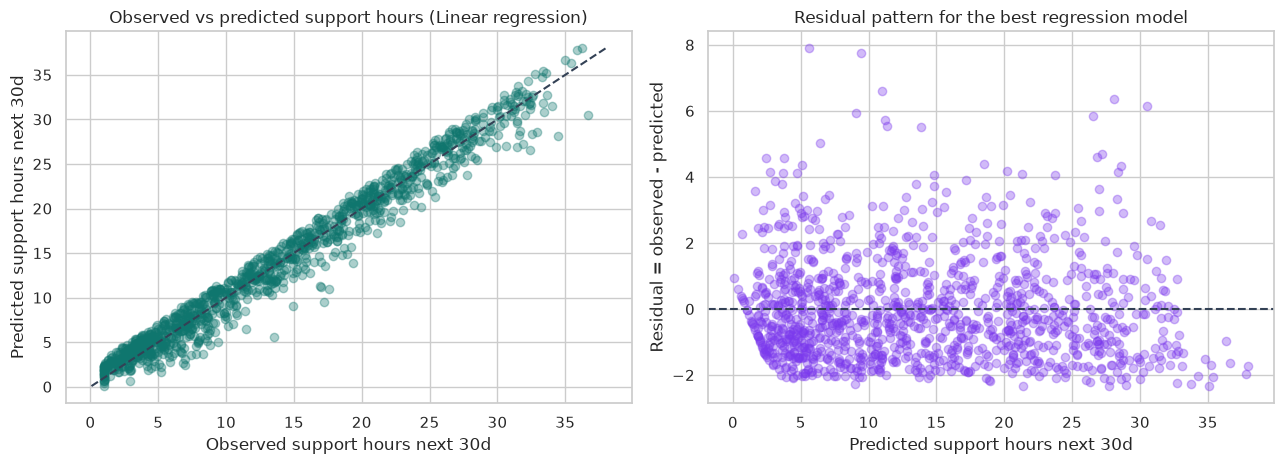

In [5]:
best_regression_predictions = regression_predictions[best_regression_name]
regression_residuals = y_reg_test - best_regression_predictions

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].scatter(y_reg_test, best_regression_predictions, alpha=0.35, color="#0f766e")
lower = min(y_reg_test.min(), best_regression_predictions.min())
upper = max(y_reg_test.max(), best_regression_predictions.max())
axes[0].plot([lower, upper], [lower, upper], linestyle="--", color="#334155", linewidth=1.5)
axes[0].set_title(f"Observed vs predicted support hours ({best_regression_name})")
axes[0].set_xlabel("Observed support hours next 30d")
axes[0].set_ylabel("Predicted support hours next 30d")

axes[1].scatter(best_regression_predictions, regression_residuals, alpha=0.35, color="#7c3aed")
axes[1].axhline(0, linestyle="--", color="#334155", linewidth=1.5)
axes[1].set_title("Residual pattern for the best regression model")
axes[1].set_xlabel("Predicted support hours next 30d")
axes[1].set_ylabel("Residual = observed - predicted")

plt.tight_layout()
plt.show()

Read the plot as a diagnostic for the workflow. The main question is what visible pattern would change the analysis in Supervised Learning: Forecasting Burden and Risk. Clean separation makes a simple rule easier to defend. Overlap or unusual tails call for more careful diagnostics.


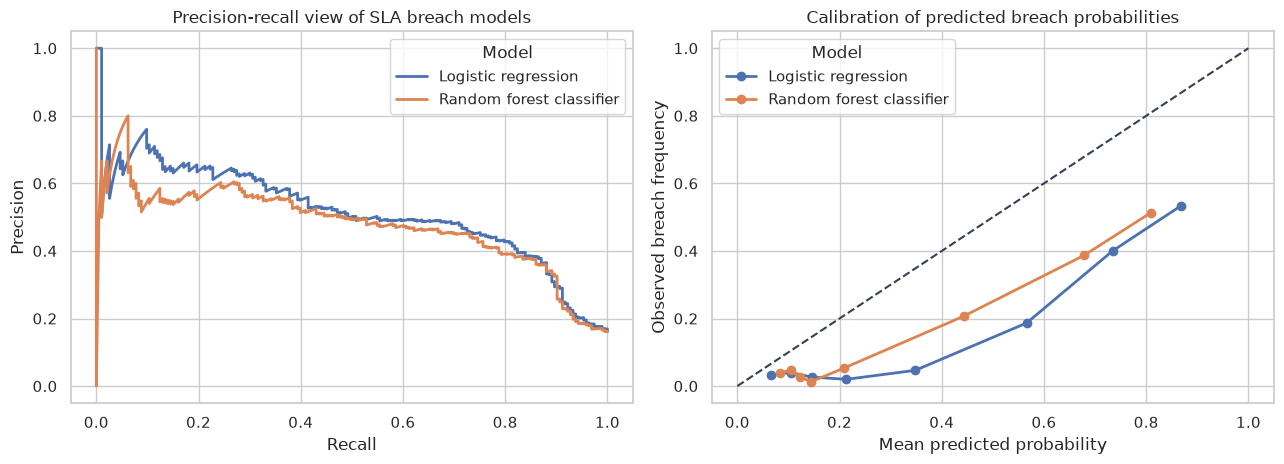

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for name, probs in classification_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_clf_test, probs)
    axes[0].plot(recall, precision, linewidth=2, label=name)

    frac_positive, mean_predicted = calibration_curve(y_clf_test, probs, n_bins=8, strategy="quantile")
    axes[1].plot(mean_predicted, frac_positive, marker="o", linewidth=2, label=name)

axes[0].set_title("Precision-recall view of SLA breach models")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend(title="Model")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="#334155", linewidth=1.5)
axes[1].set_title("Calibration of predicted breach probabilities")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Observed breach frequency")
axes[1].legend(title="Model")

plt.tight_layout()
plt.show()

This result sits between model performance and the operating policy. The useful reading is which metric would change the action in Supervised Learning: Forecasting Burden and Risk. When metrics disagree, choose the rule after naming the cost, capacity, or governance priority.


### Discussion of Supervised Results

When you run the previous cells in this simulation, you may notice that the simple baselines are surprisingly competitive. Here, linear regression slightly outperforms the random forest on RMSE and $R^2$, and logistic regression slightly outperforms the forest on ROC AUC and PR AUC, even though the data-generating process contains some nonlinear structure. That is a useful lesson in itself: strong baselines are hard to beat when the signal is smooth and well aligned with the available features.

The regression plots should also make the decision-science point clear. A model can have a respectable average error while still missing badly in parts of the distribution that matter operationally. Residual inspection is therefore not optional.

For the classification task, probability quality matters as much as discrimination. In this run, the logistic model discriminates slightly better, while the forest achieves a slightly lower Brier score. Both calibration curves still deviate from the 45-degree line in the upper bins, so neither model should be treated as perfectly calibrated without further adjustment. Ranking alone is not enough when the downstream decision depends on absolute risk.

## 4. Unsupervised Learning: Segments and Structure Discovery

Unsupervised learning begins without labeled outcomes. The goal is not to forecast a target but to discover structure in the feature space.

For this lecture, clustering is useful because operations teams often need differentiated service strategies before they have a clean label for every downstream event. Segmentation can identify recurring account profiles, which can then be reviewed by domain experts and connected to workflow design.

K-means clustering is an especially important baseline. Its objective is to partition observations into $k$ clusters by minimizing within-cluster squared distance:

$$
\min_{c_1, \ldots, c_n, \mu_1, \ldots, \mu_k} \sum_{i=1}^n \lVert x_i - \mu_{c_i} \rVert_2^2.
$$

The method is simple and often useful, but it imposes strong geometric assumptions. That is why interpretation should always involve diagnostic review rather than blind acceptance.

In [7]:
# Section focus: 4. Unsupervised Learning: Segments and Structure Discovery.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

cluster_features = [
    "annual_revenue_k",
    "seat_count",
    "usage_intensity",
    "integration_complexity",
    "prior_tickets_30d",
    "avg_response_minutes_last90d",
    "training_completion_rate",
    "feature_adoption_rate",
]

cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(data[cluster_features])

kmeans = KMeans(n_clusters=4, n_init="auto", random_state=42)
cluster_id_raw = kmeans.fit_predict(X_cluster)

center_table = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_features)
cluster_rank = center_table["integration_complexity"].sort_values().index.tolist()
cluster_name_map = {old: f"Cluster {new}" for new, old in enumerate(cluster_rank, start=1)}

data["cluster_name"] = pd.Categorical(
    pd.Series(cluster_id_raw).map(cluster_name_map),
    categories=[f"Cluster {i}" for i in range(1, 5)],
    ordered=True,
)

cluster_profile = (
    data.groupby("cluster_name", observed=True)
    .agg(
        n_accounts=("cluster_name", "size"),
        annual_revenue_k=("annual_revenue_k", "mean"),
        seat_count=("seat_count", "mean"),
        usage_intensity=("usage_intensity", "mean"),
        integration_complexity=("integration_complexity", "mean"),
        prior_tickets_30d=("prior_tickets_30d", "mean"),
        training_completion_rate=("training_completion_rate", "mean"),
        feature_adoption_rate=("feature_adoption_rate", "mean"),
        observed_breach_rate=("sla_breach_next_30d", "mean"),
        dominant_plan=("plan_tier", modal_value),
        dominant_true_segment=("true_segment", modal_value),
    )
    .reset_index()
)

cluster_story_map = cluster_profile.set_index("cluster_name")["dominant_true_segment"].to_dict()
data["cluster_story"] = data["cluster_name"].map(cluster_story_map)

cluster_alignment = pd.crosstab(
    data["true_segment"],
    data["cluster_name"],
    normalize="index",
).round(3)

silhouette = silhouette_score(X_cluster, cluster_id_raw)

smart_display(cluster_profile)
smart_display(cluster_alignment)
print(f"Silhouette score: {silhouette:.3f}")

,cluster_name,n_accounts,annual_revenue_k,seat_count,usage_intensity,integration_complexity,prior_tickets_30d,training_completion_rate,feature_adoption_rate,observed_breach_rate,dominant_plan,dominant_true_segment
0,Cluster 1,1610,47.552,32.411,0.398,0.220,1.816,0.713,0.586,0.032,basic,Self-serve SMB
1,Cluster 2,1375,132.830,116.750,0.700,0.438,4.380,0.630,0.749,0.041,professional,Growth mid-market
2,Cluster 3,777,187.571,148.004,0.626,0.645,7.443,0.325,0.330,0.326,business,Distressed high-risk
3,Cluster 4,1038,381.253,327.660,0.734,0.746,9.202,0.582,0.612,0.398,enterprise,Complex enterprise


cluster_name,Cluster 1,Cluster 2,Cluster 3,Cluster 4
true_segment,,,,
Self-serve SMB,0.948,0.051,0.001,0.000
Growth mid-market,0.065,0.887,0.046,0.001
Complex enterprise,0.000,0.024,0.034,0.942
Distressed high-risk,0.006,0.038,0.944,0.013


Silhouette score: 0.286


In Unsupervised Learning: Segments and Structure Discovery, the point of the output is practical. It should help narrow the model choice, choose the next diagnostic, set a threshold, or define a guardrail.


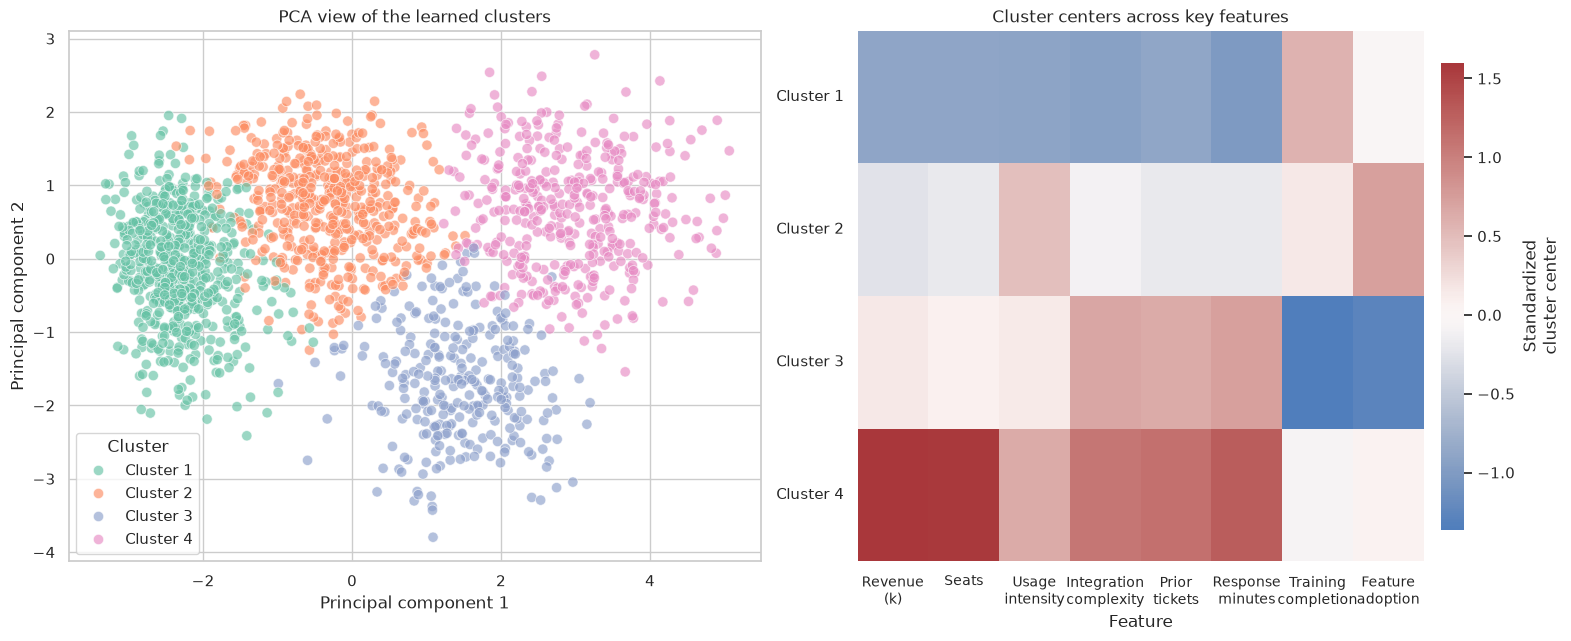

In [8]:
# Section focus: 4. Unsupervised Learning: Segments and Structure Discovery.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

embedding = PCA(n_components=2, random_state=42).fit_transform(X_cluster)
cluster_order = [f"Cluster {i}" for i in range(1, 5)]

embedding_df = pd.DataFrame(
    {
        "PC1": embedding[:, 0],
        "PC2": embedding[:, 1],
        "cluster_name": data["cluster_name"].astype(str),
    }
)
embedding_df["cluster_name"] = pd.Categorical(
    embedding_df["cluster_name"],
    categories=cluster_order,
    ordered=True,
)

ordered_centers = center_table.copy()
ordered_centers.index = [cluster_name_map[idx] for idx in ordered_centers.index]
ordered_centers = ordered_centers.reindex(cluster_order)

heatmap_labels = [
    "Revenue\n(k)",
    "Seats",
    "Usage\nintensity",
    "Integration\ncomplexity",
    "Prior\ntickets",
    "Response\nminutes",
    "Training\ncompletion",
    "Feature\nadoption",
]
ordered_centers_display = ordered_centers.copy()
ordered_centers_display.columns = heatmap_labels

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15.6, 6.3),
    gridspec_kw={"width_ratios": [1.10, 0.90]},
    constrained_layout=True,
)

sampled_embedding = embedding_df.sample(n=min(1800, len(embedding_df)), random_state=42)
sns.scatterplot(
    data=sampled_embedding,
    x="PC1",
    y="PC2",
    hue="cluster_name",
    hue_order=cluster_order,
    palette="Set2",
    s=55,
    alpha=0.65,
    ax=axes[0],
)
axes[0].set_title("PCA view of the learned clusters")
axes[0].set_xlabel("Principal component 1")
axes[0].set_ylabel("Principal component 2")
axes[0].legend(title="Cluster", loc="best")

sns.heatmap(
    ordered_centers_display,
    cmap="vlag",
    center=0,
    ax=axes[1],
    cbar_kws={"label": "Standardized\ncluster center", "shrink": 0.88, "pad": 0.03},
)
axes[1].set_title("Cluster centers across key features")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("")
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="center")
axes[1].tick_params(axis="x", labelsize=10)

plt.show()

Unsupervised Learning: Segments and Structure Discovery gives a checkpoint for the decision workflow. Ask which pattern would change the next modeling or governance choice.


### Discussion of Unsupervised Results

The clustering results should be interpreted with two attitudes at once.

First, they are often genuinely useful. The profile table and PCA view usually reveal stable differences in scale, complexity, training quality, and support intensity. Those differences matter for operations even without a supervised target.

Second, they are not ground truth. The alignment table with the hidden `true_segment` benchmark is a reminder that clusters can approximate real structure without recovering it perfectly. In applied work, that means clusters should be treated as analytical suggestions that must be reviewed and named by domain experts.

This is one of the most important habits in machine learning for decision science: unsupervised outputs are valuable, but they should never be mistaken for discovered reality.

## 5. From Model Outputs to Operational Recommendations

A useful notebook cannot stop at metrics. The next step is to convert predictions and segments into a practical action policy.

Below is a deliberately simple operating rule. It is not meant to be optimal. It is meant to show how statistical learning outputs become workload triage.

| Signal pattern | Operational interpretation | Candidate action |
|---|---|---|
| Very high predicted breach probability | Service failure is likely without intervention | Escalate to specialist success team |
| Moderate predicted breach probability or high predicted support burden | Account may destabilize soon | Proactive outreach and monitoring |
| Low predicted breach probability and modest burden | Standard support is usually enough | Standard digital support |

Notice the logic here. We are not claiming these actions *cause* improvement. We are using predictive evidence to prioritize attention. Causal methods become necessary once the question shifts from *who looks risky?* to *which intervention actually improves outcomes for whom?*

In [9]:
# Section focus: 5. From Model Outputs to Operational Recommendations.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

test_frame = test_df.copy()
test_frame["predicted_support_hours"] = regression_predictions[best_regression_name]
test_frame["predicted_breach_probability"] = classification_probabilities[best_classification_name]
test_frame["cluster_name"] = data.loc[test_frame.index, "cluster_name"].values
test_frame["cluster_story"] = data.loc[test_frame.index, "cluster_story"].values


def recommend_action(row):
    """Carry out the recommend action step used in the 01. Statistical Learning for Decision Systems workflow.
    
    Parameters
    ----------
    row : object
        Single data-frame row representing one unit in the current decision example.
    
    Returns
    -------
    object
        Decision recommendation or policy object produced by the recommend action workflow.
    """
    if row["predicted_breach_probability"] >= 0.55:
        return "Escalate to specialist team"
    if row["predicted_breach_probability"] >= 0.18 or row["predicted_support_hours"] >= 11:
        return "Proactive outreach and monitoring"
    return "Standard digital support"


test_frame["recommended_action"] = test_frame.apply(recommend_action, axis=1)

action_summary = (
    test_frame.groupby("recommended_action")
    .agg(
        n_accounts=("recommended_action", "size"),
        mean_predicted_breach_probability=("predicted_breach_probability", "mean"),
        observed_breach_rate=("sla_breach_next_30d", "mean"),
        mean_predicted_support_hours=("predicted_support_hours", "mean"),
        mean_actual_support_hours=("support_hours_next_30d", "mean"),
    )
    .sort_values("mean_predicted_breach_probability", ascending=False)
    .reset_index()
)

cluster_action_mix = pd.crosstab(
    test_frame["cluster_story"],
    test_frame["recommended_action"],
    normalize="index",
).round(3)

smart_display(action_summary)
smart_display(cluster_action_mix)

,recommended_action,n_accounts,mean_predicted_breach_probability,observed_breach_rate,mean_predicted_support_hours,mean_actual_support_hours
0,Escalate to specialist team,397,0.752416,0.400504,24.594179,24.515880
1,Proactive outreach and monitoring,338,0.319411,0.053254,13.358077,13.400583
2,Standard digital support,465,0.107924,0.034409,5.267900,5.214013


recommended_action,Escalate to specialist team,Proactive outreach and monitoring,Standard digital support
cluster_story,,,
Self-serve SMB,0.000000,0.101000,0.899000
Growth mid-market,0.025000,0.654000,0.321000
Distressed high-risk,0.780000,0.220000,0.000000
Complex enterprise,0.919000,0.081000,0.000000


Read this as the point where statistical evidence starts to shape deployment. The useful reading is which metric would change the action in From Model Outputs to Operational Recommendations. When metrics disagree, the operating priority should come first.


### Discussion of the Action Readout

When you run the final action cell, you should see that the recommended actions are ordered by risk and expected burden in a sensible way. The specialist queue should contain a smaller set of accounts with much worse realized breach outcomes and much heavier support demand, while the standard-support queue should contain lower-risk and lower-burden accounts.

The middle proactive queue is usually closer to the standard queue on realized breach rate than to the specialist queue, but it still carries noticeably higher expected and realized workload. In other words, this middle tier behaves more like a workload-management tier than a pure failure-risk tier. That is still useful, because many operating decisions depend on both risk and burden.

But the notebook should also leave you with a healthy caution. This analysis is predictive, not causal. It helps determine where to look and where to allocate attention. It does **not** tell us whether proactive outreach, specialist routing, or digital self-service will actually improve outcomes. That is where later causal courses reconnect to machine learning.

## Wrap-Up

This lecture introduced statistical learning as a decision-science workflow rather than a menu of algorithms.

The main lessons are:

1. A learning problem begins with an action problem and a loss structure.
2. Supervised learning helps forecast burden and rank risk when labeled outcomes exist.
3. Unsupervised learning helps discover structure when labels are unavailable or incomplete.
4. Metrics matter only insofar as they support a practical decision.
5. Segmentation can be operationally useful even when it is not perfect.
6. Predictive models support triage and prioritization, but they do not answer causal questions by themselves.

The rest of the course will unpack each of these pieces more carefully. Later notebooks will go deeper into leakage control, baselines, regularization, tree models, clustering methods, dimensionality reduction, tuning, drift, and the conversion of model output into disciplined operating policies.

## References

- Breiman, L. (2001). *Statistical Modeling: The Two Cultures (with comments and a rejoinder by the author).* *Statistical Science*, 16(3). [https://doi.org/10.1214/ss/1009213726](https://doi.org/10.1214/ss/1009213726)
- Bzdok, D., Altman, N., & Krzywinski, M. (2018). *Statistics versus machine learning.* *Nature Methods*, 15(4), 233-234. [https://doi.org/10.1038/nmeth.4642](https://doi.org/10.1038/nmeth.4642)
- Hastie, T., Tibshirani, R., & Friedman, J. H. (2009). *The Elements of Statistical Learning.* Springer. [https://doi.org/10.1007/978-0-387-84858-7](https://doi.org/10.1007/978-0-387-84858-7)
- Jain, A. K. (2010). *Data clustering: 50 years beyond K-means.* *Pattern Recognition Letters*, 31(8), 651-666. [https://doi.org/10.1016/j.patrec.2009.09.011](https://doi.org/10.1016/j.patrec.2009.09.011)
- Niculescu-Mizil, A., & Caruana, R. (2005). *Predicting good probabilities with supervised learning.* [https://doi.org/10.1145/1102351.1102430](https://doi.org/10.1145/1102351.1102430)
